In [1]:
import os
from google.colab import drive

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_703db1c40fe18c57c118e623ed0c60a8'

drive.mount('/content/drive')

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/dataset/

print("Đã tải và giải nén dữ liệu hoàn tất!")

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:10<00:00, 18.8MB/s]

Đã tải và giải nén dữ liệu hoàn tất!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[*] Đã bật chế độ Mixed Precision (Keras AMP) cho GPU!

--- Đang kiểm tra và dọn dẹp ảnh lỗi (File hỏng) ---
Đã dọn dẹp xong! Xóa 0 file lỗi.

--- Đang gộp 16 ảnh từ 'val' cũ vào 'train' để chia lại ---

--- Đang tải dữ liệu lên RAM ---
Found 4448 images belonging to 2 classes.
Found 784 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Trọng số lớp: NORMAL = 1.94, PNEUMONIA = 0.67


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Bắt đầu huấn luyện CNN ---
Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.7256 - loss: 2.5560
Epoch 1: val_accuracy improved from None to 0.74235, saving model to /content/chest_xray_best_model.keras

Epoch 1: finished saving model to /content/chest_xray_best_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 67s 362ms/step - accuracy: 0.7925 - loss: 1.2762 - val_accuracy: 0.7423 - val_loss: 9.0868 - learning_rate: 0.0010
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.8714 - loss: 0.4338
Epoch 2: val_accuracy did not improve from 0.74235
139/139 ━━━━━━━━━━━━━━━━━━━━ 45s 323ms/step - accuracy: 0.8856 - loss: 0.4167 - val_accuracy: 0.7423 - val_loss: 6.4241 - learning_rate: 0.0010
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9062 - loss: 0.3912
Epoch 3: val_accuracy did not improve from 0.74235
139/139 ━━━━━━━━━━━━━━━━━━━━ 44s 317ms/step - accuracy: 0.9103 - loss: 0.3848 - val_accuracy: 0.7423 - val_loss: 0.9927 - learning_rate:

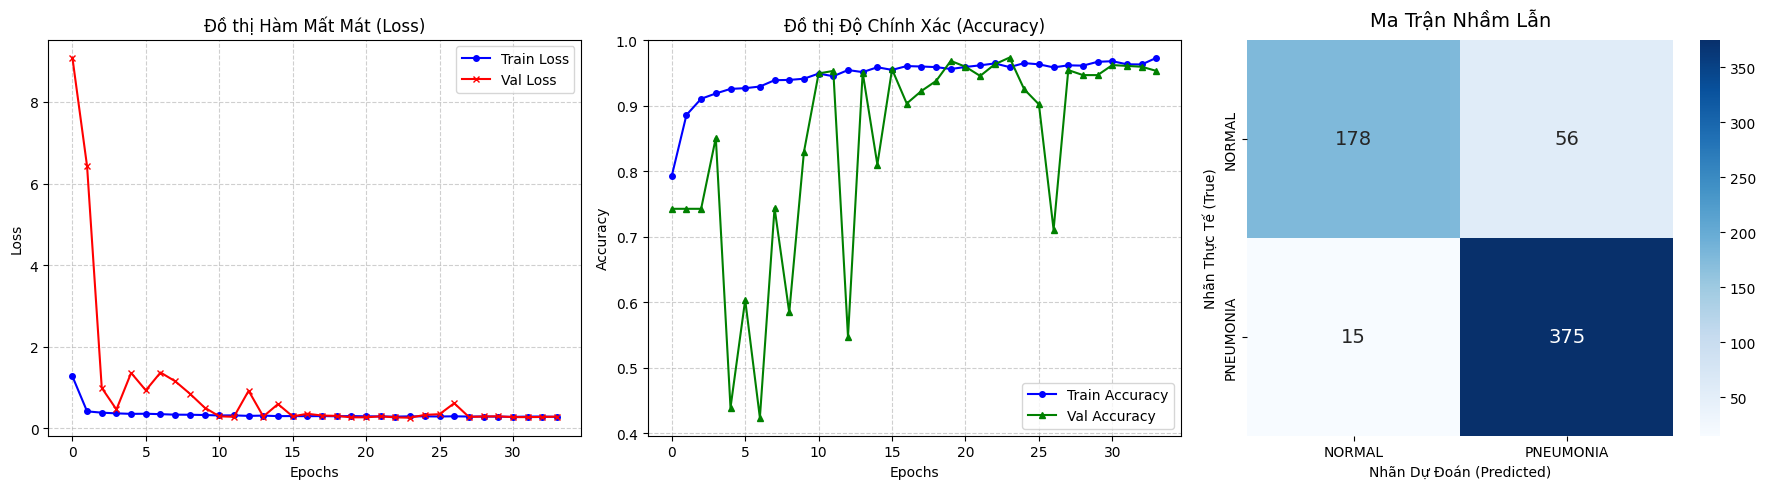

In [4]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# ==============================================================================
# BƯỚC 0: TỐI ƯU HÓA GPU VỚI MIXED PRECISION (Tăng tốc độ train x2)
# ==============================================================================
mixed_precision.set_global_policy('mixed_float16')
print("[*] Đã bật chế độ Mixed Precision (Keras AMP) cho GPU!")

# ==============================================================================
# BƯỚC 1: CẤU HÌNH KAGGLE & TẢI DỮ LIỆU
# ==============================================================================
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_703db1c40fe18c57c118e623ed0c60a8'
if not os.path.exists('/content/dataset/chest_xray'):
    print("Đang tải dữ liệu từ Kaggle...")
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
    print("Đang giải nén dữ liệu...")
    !unzip -o -q chest-xray-pneumonia.zip -d /content/dataset/

# ==============================================================================
# BƯỚC 2: DỌN DẸP ẢNH LỖI VÀ GỘP TẬP VAL CŨ VÀO TRAIN
# ==============================================================================
base_dir = '/content/dataset/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir_old = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

print("\n--- Đang kiểm tra và dọn dẹp ảnh lỗi (File hỏng) ---")
removed_count = 0
for folder in [train_dir, val_dir_old, test_dir]:
    if os.path.exists(folder):
        for root, dirs, files in os.walk(folder):
            for file in files:
                file_path = os.path.join(root, file)
                try:
                    img = Image.open(file_path)
                    img.verify()
                except Exception:
                    os.remove(file_path)
                    removed_count += 1
print(f"Đã dọn dẹp xong! Xóa {removed_count} file lỗi.")

print("\n--- Đang gộp 16 ảnh từ 'val' cũ vào 'train' để chia lại ---")
for category in ['NORMAL', 'PNEUMONIA']:
    old_val_path = os.path.join(val_dir_old, category)
    train_cat_path = os.path.join(train_dir, category)
    if os.path.exists(old_val_path):
        for img_file in os.listdir(old_val_path):
            src = os.path.join(old_val_path, img_file)
            dst = os.path.join(train_cat_path, img_file)
            if not os.path.exists(dst):
                shutil.copy(src, dst)

# ==============================================================================
# BƯỚC 3: TIỀN XỬ LÝ & DATA AUGMENTATION
# ==============================================================================
IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

print("\n--- Đang tải dữ liệu lên RAM ---")
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale', subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale', subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale', shuffle=False
)

# ==============================================================================
# BƯỚC 4: TÍNH TOÁN TRỌNG SỐ LỚP (CLASS WEIGHTS)
# ==============================================================================
num_normal = train_generator.classes.tolist().count(0)
num_pneumonia = train_generator.classes.tolist().count(1)
total = num_normal + num_pneumonia

weight_for_0 = (1 / num_normal) * (total / 2.0)
weight_for_1 = (1 / num_pneumonia) * (total / 2.0)
class_weights = {0: weight_for_0, 1: weight_for_1}
print(f"\nTrọng số lớp: NORMAL = {weight_for_0:.2f}, PNEUMONIA = {weight_for_1:.2f}")

# ==============================================================================
# BƯỚC 5: XÂY DỰNG KIẾN TRÚC CUSTOM CNN
# ==============================================================================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    # Bắt buộc dtype='float32' ở layer cuối khi dùng Mixed Precision
    Dense(1, activation='sigmoid', dtype='float32')
])

# Bổ sung Label Smoothing = 0.1 để chống Overfitting
loss_fn = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1)
model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])

# ==============================================================================
# BƯỚC 6: CẤU HÌNH CALLBACKS & HUẤN LUYỆN
# ==============================================================================
checkpoint_path = '/content/chest_xray_best_model.keras'

callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
]

print("\n--- Bắt đầu huấn luyện CNN ---")
epochs = 50
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks
)

# ==============================================================================
# BƯỚC 7: ĐÁNH GIÁ TRÊN TẬP TEST & BÁO CÁO
# ==============================================================================
print("\n--- Đánh giá kết quả trên tập Test ---")
model.load_weights(checkpoint_path)
test_loss, test_acc = model.evaluate(test_generator)
print(f"Độ chính xác trên tập Test (Test Accuracy): {test_acc*100:.2f}%\n")

test_generator.reset()
preds = model.predict(test_generator)
preds_classes = np.where(preds > 0.5, 1, 0) # Bạn có thể đổi thành 0.6 hoặc 0.7 ở đây
true_classes = test_generator.classes

print("BÁO CÁO PHÂN LOẠI:")
print(classification_report(true_classes, preds_classes, target_names=['NORMAL', 'PNEUMONIA']))

# ==============================================================================
# BƯỚC 8: VẼ ĐỒ THỊ CHUYÊN NGHIỆP (LOSS, ACCURACY & CONFUSION MATRIX)
# ==============================================================================
plt.figure(figsize=(18, 5))

# 1. Đồ thị Loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(history.history['val_loss'], label='Val Loss', color='red', marker='x', markersize=4)
plt.title('Đồ thị Hàm Mất Mát (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 2. Đồ thị Accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', marker='o', markersize=4)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='green', marker='^', markersize=4)
plt.title('Đồ thị Độ Chính Xác (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 3. Ma Trận Nhầm Lẫn (Confusion Matrix)
plt.subplot(1, 3, 3)
cm = confusion_matrix(true_classes, preds_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'],
            annot_kws={"size": 14})
plt.title('Ma Trận Nhầm Lẫn', fontsize=14, pad=10)
plt.ylabel('Nhãn Thực Tế (True)')
plt.xlabel('Nhãn Dự Đoán (Predicted)')

plt.tight_layout()
plt.show()

In [5]:
!pip install transformers torch torchvision scikit-learn

[*] Đang chạy trên thiết bị: cuda

--- Đang kiểm tra và dọn dẹp các file ảnh bị lỗi... ---
Đã dọn dẹp xong! Số lượng file lỗi bị xóa: 0

--- Đang gộp và chia lại tập Train / Validation... ---
Số ảnh Train mới: 4460 | Val mới: 788
Trọng số lớp đã tính: Normal=1.93, Pneumonia=0.67

--- Đang tải mô hình Vision Transformer (HuggingFace)... ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



--- Bắt đầu huấn luyện ViT... ---
Epoch 1/10 [262.1s] - Train Loss: 0.1615 - Val Acc: 97.72%
  -> Đã lưu model tốt nhất (Acc: 97.72%)
Epoch 2/10 [254.2s] - Train Loss: 0.0899 - Val Acc: 95.81%
Epoch 3/10 [254.6s] - Train Loss: 0.0585 - Val Acc: 94.54%
Epoch 4/10 [256.1s] - Train Loss: 0.0508 - Val Acc: 96.45%
Epoch 5/10 [255.2s] - Train Loss: 0.0351 - Val Acc: 97.97%
  -> Đã lưu model tốt nhất (Acc: 97.97%)
Epoch 6/10 [256.0s] - Train Loss: 0.0179 - Val Acc: 98.10%
  -> Đã lưu model tốt nhất (Acc: 98.10%)
Epoch 7/10 [255.4s] - Train Loss: 0.0189 - Val Acc: 97.34%
Epoch 8/10 [254.9s] - Train Loss: 0.0314 - Val Acc: 98.35%
  -> Đã lưu model tốt nhất (Acc: 98.35%)
Epoch 9/10 [256.2s] - Train Loss: 0.0184 - Val Acc: 97.97%
Epoch 10/10 [258.4s] - Train Loss: 0.0139 - Val Acc: 97.84%

--- Đánh giá mô hình trên tập Test ---

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      NORMAL       0.99      0.59      0.74       234
   PNEUMONIA       0.80      1.00      0.

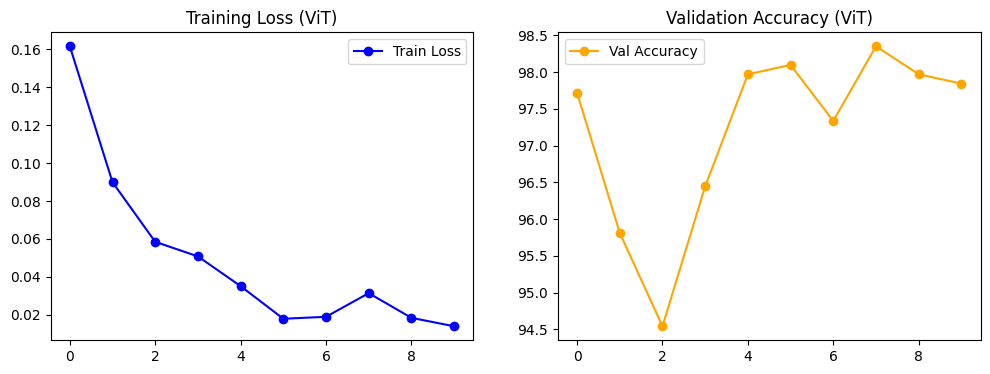

In [6]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, ConcatDataset
from transformers import ViTForImageClassification
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image

# ==============================================================================
# BƯỚC 1: CẤU HÌNH KAGGLE VÀ TẢI DỮ LIỆU
# ==============================================================================
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_703db1c40fe18c57c118e623ed0c60a8'
if not os.path.exists('/content/dataset/chest_xray'):
    print("Đang tải dữ liệu từ Kaggle...")
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
    print("Đang giải nén dữ liệu...")
    !unzip -o -q chest-xray-pneumonia.zip -d /content/dataset/
    print("Đã tải và giải nén xong!")

# ==============================================================================
# BƯỚC 2: CẤU HÌNH ĐƯỜNG DẪN VÀ DỌN DẸP ẢNH LỖI
# ==============================================================================
DATA_DIR = '/content/dataset/chest_xray'
MODEL_PATH = '/content/vit_chest_xray_pytorch_best.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Đang chạy trên thiết bị: {device}")

print("\n--- Đang kiểm tra và dọn dẹp các file ảnh bị lỗi... ---")
folders_to_check = [os.path.join(DATA_DIR, 'train'), os.path.join(DATA_DIR, 'val'), os.path.join(DATA_DIR, 'test')]
removed_count = 0
for folder in folders_to_check:
    if os.path.exists(folder):
        for root, dirs, files in os.walk(folder):
            for file in files:
                file_path = os.path.join(root, file)
                try:
                    img = Image.open(file_path)
                    img.verify()
                except Exception:
                    os.remove(file_path)
                    removed_count += 1
print(f"Đã dọn dẹp xong! Số lượng file lỗi bị xóa: {removed_count}")

# ==============================================================================
# BƯỚC 3: ĐỊNH NGHĨA TIỀN XỬ LÝ (TRANSFORMS) - 224x224 CHO ViT
# ==============================================================================
IMAGE_SIZE = 224
BATCH_SIZE = 32

transform_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==============================================================================
# BƯỚC 4: GỘP TRAIN + VAL CŨ VÀ CHIA LẠI TỶ LỆ
# ==============================================================================
print("\n--- Đang gộp và chia lại tập Train / Validation... ---")
full_train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'))
val_dataset_old = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'))

# Gộp dữ liệu thô (chưa transform)
combined_dataset = ConcatDataset([full_train_dataset, val_dataset_old])
all_labels = [label for _, label in combined_dataset]

# Chia 85% Train - 15% Validation
train_idx, val_idx = train_test_split(list(range(len(all_labels))), test_size=0.15, random_state=42, stratify=all_labels)

# Custom class để áp dụng transform khác nhau
class CustomSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform: image = self.transform(image)
        return image, label
    def __len__(self): return len(self.indices)

train_dataset = CustomSubset(combined_dataset, train_idx, transform=transform_train)
val_dataset = CustomSubset(combined_dataset, val_idx, transform=transform_val_test)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Số ảnh Train mới: {len(train_dataset)} | Val mới: {len(val_dataset)}")

# ==============================================================================
# BƯỚC 5: TÍNH TOÁN TRỌNG SỐ LỚP (CLASS WEIGHTS)
# ==============================================================================
train_labels = [all_labels[i] for i in train_idx]
class_counts = np.bincount(train_labels)
weights = sum(class_counts) / (len(class_counts) * class_counts)
class_weights = torch.FloatTensor(weights).to(device)
print(f"Trọng số lớp đã tính: Normal={weights[0]:.2f}, Pneumonia={weights[1]:.2f}")

# ==============================================================================
# BƯỚC 6: KHỞI TẠO MÔ HÌNH VISION TRANSFORMER (ViT)
# ==============================================================================
print("\n--- Đang tải mô hình Vision Transformer (HuggingFace)... ---")
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True
).to(device)

# ==============================================================================
# BƯỚC 7: CẤU HÌNH HUẤN LUYỆN
# ==============================================================================
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

# ĐÃ SỬA LỖI Ở ĐÂY: Xóa bỏ tham số verbose=True
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

num_epochs = 10
best_acc = 0.0
history = {'train_loss': [], 'val_acc': []}

# ==============================================================================
# BƯỚC 8: VÒNG LẶP HUẤN LUYỆN
# ==============================================================================
print("\n--- Bắt đầu huấn luyện ViT... ---")
for epoch in range(num_epochs):
    start_time = time.time()

    # Huấn luyện (Train)
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Đánh giá (Validation)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs).logits
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)

    # Cập nhật Scheduler
    scheduler.step(val_acc)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} [{epoch_time:.1f}s] - Train Loss: {avg_train_loss:.4f} - Val Acc: {val_acc:.2f}%")

    # Lưu mô hình tốt nhất
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  -> Đã lưu model tốt nhất (Acc: {val_acc:.2f}%)")

# ==============================================================================
# BƯỚC 9: ĐÁNH GIÁ TRÊN TẬP TEST VÀ VẼ BIỂU ĐỒ
# ==============================================================================
print("\n--- Đánh giá mô hình trên tập Test ---")
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

all_preds, all_labels_test = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs).logits
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(all_labels_test, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

# Vẽ đồ thị
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.title('Training Loss (ViT)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='orange', marker='o')
plt.title('Validation Accuracy (ViT)')
plt.legend()
plt.show()

=== ĐANG VẼ MA TRẬN NHẦM LẪN CHO ViT ===


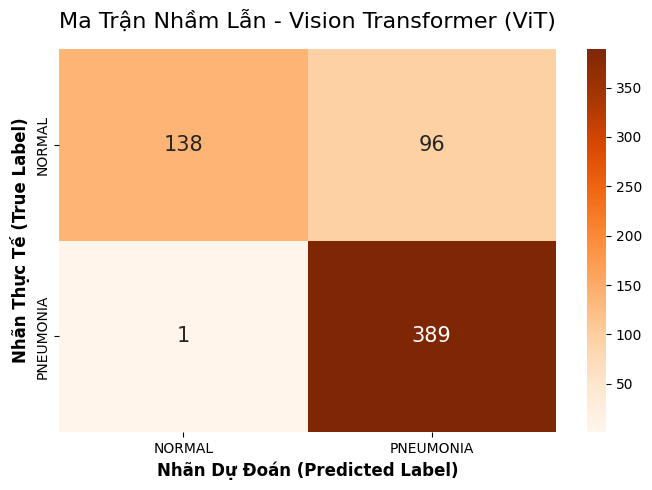

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("=== ĐANG VẼ MA TRẬN NHẦM LẪN CHO ViT ===")

# 1. Tính toán ma trận nhầm lẫn từ kết quả test của ViT
cm_vit = confusion_matrix(all_labels_test, all_preds)

# 2. Khởi tạo khung vẽ
plt.figure(figsize=(7, 5))

# 3. Vẽ biểu đồ nhiệt (Heatmap)
# Sử dụng cmap='Oranges' (Tông màu cam) để phân biệt với biểu đồ CNN
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"],
            annot_kws={"size": 15}) # Phóng to font chữ số bên trong ô

# 4. Tùy chỉnh nhãn và tiêu đề
plt.title('Ma Trận Nhầm Lẫn - Vision Transformer (ViT)', fontsize=16, pad=15)
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12, fontweight='bold')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12, fontweight='bold')

# 5. Hiển thị biểu đồ
plt.tight_layout()
plt.show()